# Lab Assignment - 3

## Scikit-learn: Data Preprocessing and Model Performance Evaluation

### Part A - Data Loading and Preprocessing with Scikit-learn
#### Task 1 - Load and Understand the Dataset

In [91]:
import numpy as np #numerical arrays and mathematical operations
import pandas as pd #tables/DataFrames and data manipulation
import matplotlib.pyplot as plt # for customizing and displaying plots
import seaborn as sns # for statistical visualizations

In [92]:
df = pd.read_csv("hotel_bookings.csv")  #load the dataset
df.head() #display 5 top rows of the dataset


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [93]:
print("\nShape of dataset: ", df.shape) #shape of dataser(number of rows and col)

print("\nData types of dataset: ",df.dtypes) #the data types


Shape of dataset:  (119390, 32)

Data types of dataset:  hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type      

In [94]:
df.info #information about dataset

<bound method DataFrame.info of                hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27  

In [95]:
df.describe() #Summary statistics for numerical columns


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [96]:
#Check the class distribution of is_canceled and use it as the target y.
# is_canceled: 0 = not canceled, 1 = canceled
print(df["is_canceled"].value_counts())
print(df["is_canceled"].value_counts(normalize=True) * 100)  # as percentages

0    75166
1    44224
Name: is_canceled, dtype: int64
0    62.958372
1    37.041628
Name: is_canceled, dtype: float64


In [97]:
#Create X from the remaining usable features. Identify numerical and categorical columns.
#  target y 
y = df["is_canceled"]

#  X 
X = df.drop(columns=["is_canceled"])

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


#### Task 2 - Missing Values, Leakage, and Outliers

In [98]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent.round(2)
})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing %", ascending=False)
print(missing_df)

          Missing Count  Missing %
company          112593      94.31
agent             16340      13.69
country             488       0.41
children              4       0.00


##### Observation
As we can see attribute company had 94.31% missing values so it is  dropped entirely. At this level of missingness,the column carries almost no usable signal

And agent attribute has (13.69% missing) and country has (0.41% missing) were retained. Their missingness is moderate-to-negligible 

And children attribute had only 4 missing rows (~0.00%) — negligible.

In [99]:
#Identify columns with very high missingness. Drop them only if justified and state the reason.
high_missing_cols = ["company"]

df = df.drop(columns=high_missing_cols)
print("Dropped columns (high missingness):", high_missing_cols)
print("New shape:", df.shape)

Dropped columns (high missingness): ['company']
New shape: (119390, 31)


##### Observation
Only company attribute crosses the 90% threshold so we drop it.
Justification: 94.31% missing means the column carries almost no usable signal imputing it would mean fabricating values for the vast majority of rows.

In [100]:
#Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.
leakage_cols = ["reservation_status", "reservation_status_date"]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
print("Dropped leakage columns:", leakage_cols)

Dropped leakage columns: ['reservation_status', 'reservation_status_date']


##### Observation 
reservation_status and reservation_status_date were removed. 
Both columns are recorded only after a booking's outcome is known (e.g. reservation_status directly
contains "Canceled"/"Check-Out", which is essentially the target variable restated).

Keeping them would let the model "cheat" by learning the answer directly rather than
learning genuine predictive patterns, producing unrealistically high accuracy that
would not generalize to real-world use.

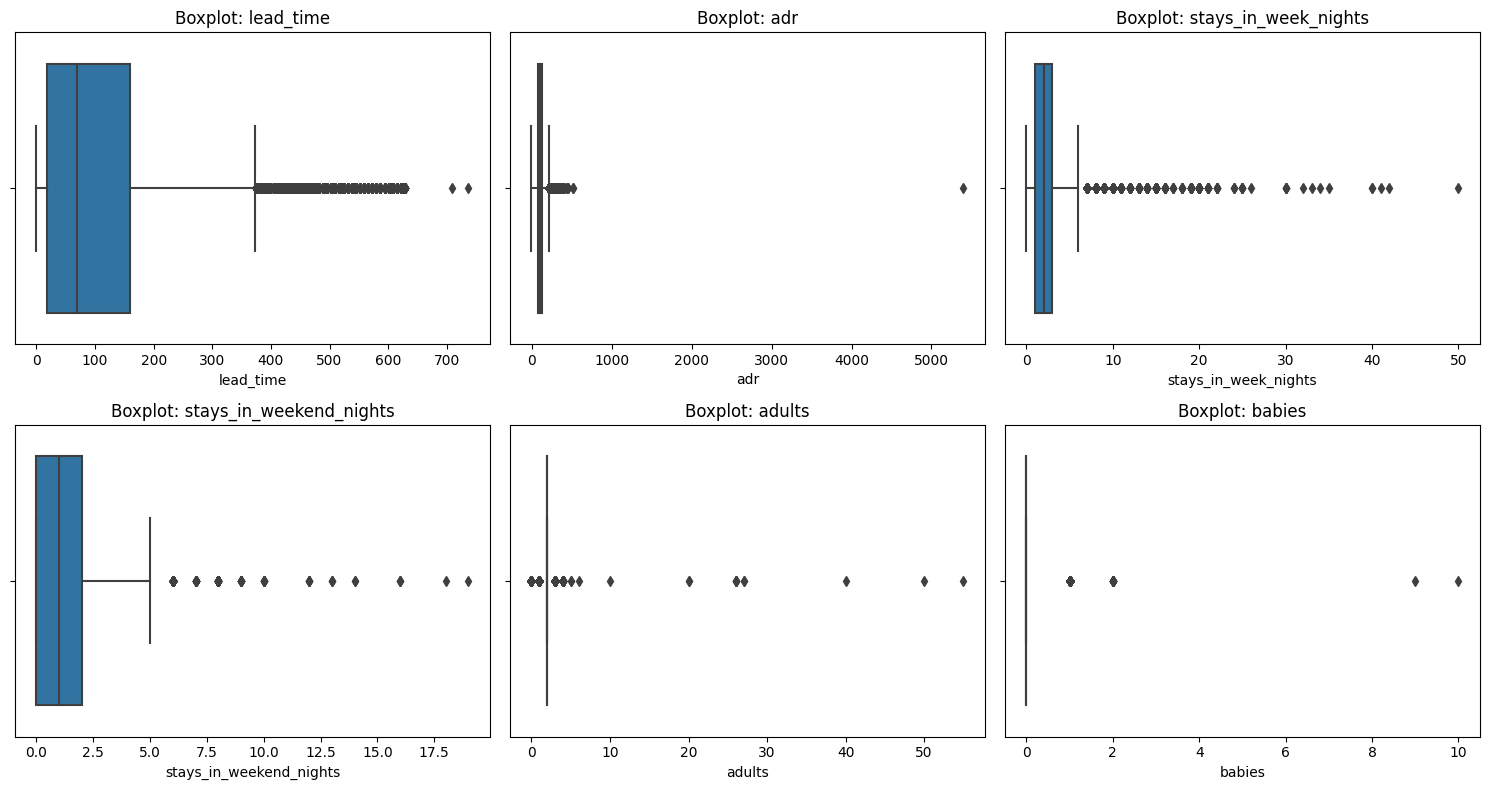

In [101]:
# To Check selected numerical features for outliers using boxplots and/or the IQR method.
outlier_check_cols = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights", "adults", "babies"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

 Boxplots on lead_time, adr,stays_in_week_nights,stays_in_weekend_nights,adults, and babies revealed extreme values inconsistent with realistic bookings.
e.g. adr (average daily rate) had a value above 5000 while the typical range is under 300, and adults/babies had values like 55 and 10 respectively, which are not possible for standard hotel bookings.

Used the IQR method with a widened multiplier (factor=3 instead of the standard 1.5)
to stay conservative and remove only clearly extreme values, not natural variation.


In [102]:
#report how many rows were removed.
def remove_extreme_outliers(data, col, factor=3):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

rows_before = df.shape[0]
for col in ["adr", "lead_time", "stays_in_week_nights", "adults", "babies"]:
    df = remove_extreme_outliers(df, col, factor=3)
rows_after = df.shape[0]

print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows removed as extreme outliers: {rows_before - rows_after}")

Rows before: 119390
Rows after:  87289
Rows removed as extreme outliers: 32101


##### Observation
Total rows removed as extreme outliers, using IQR with factor=3 to stay conservative. We remove only "clear/extreme" outliers rather than aggressively trimming naturalvariation.

In [103]:
# Final shape of dataset
y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Final X shape:", X.shape)
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Final X shape: (87289, 28)
Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


#### Observation 
Final X shape: (87289, 28) — reflects removal of company (leakage-free,high-missingness) and 'reservation_status'/'reservation_status_date' (leakage columns).


#### Task 3 - Create Two Preprocessing Pipelines

In [104]:
# Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for all experiments.

from sklearn.model_selection import train_test_split

# Stratify on y to preserve the class balance (63/37 split) in both train and test sets
# random_state=42 ensures reproducibility — same split every time we re-run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (69831, 28)
X_test shape: (17458, 28)
y_train distribution:
 0    0.604631
1    0.395369
Name: is_canceled, dtype: float64
y_test distribution:
 0    0.604651
1    0.395349
Name: is_canceled, dtype: float64


##### Observation
80/20 split with stratification on is_canceled ensures both train and test sets preserve the original ~63% not-canceled / ~37% canceled ratio. 

In [110]:
from sklearn.pipeline import Pipeline # Importing tools needed for preprocessing the dataset
from sklearn.compose import ColumnTransformer # Helps apply different preprocessing to numerical and categorical columns
from sklearn.impute import KNNImputer, SimpleImputer # Methods for handling missing values
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder # Methods used to scale numerical data and encode categorical data

In [ ]:
# Numerical pipeline pieces
# KNNImputer fills missing numerical values using the 5 nearest neighbors' values,
# which is more context-aware than a simple mean/median fill.
numeric_transformer_std = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())   # Pipeline A: standardizes to mean=0, std=1
])

numeric_transformer_minmax = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())     # Pipeline B: scales to a fixed [0, 1] range
])

# Categorical pipeline pieces (same for both pipelines) 
# SimpleImputer fills missing categories with the most frequent value in that column.
# OneHotEncoder converts categories into binary columns; handle_unknown="ignore"
# prevents errors if the test set has a category never seen during training.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [107]:
# ColumnTransformer applies the right preprocessing to the right column type,
# and concatenates the results into a single feature matrix.

# Pipeline A: numerical -> KNNImputer + StandardScaler
preprocessor_A = ColumnTransformer(transformers=[
    ("num", numeric_transformer_std, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Pipeline B: numerical -> KNNImputer + MinMaxScaler
preprocessor_B = ColumnTransformer(transformers=[
    ("num", numeric_transformer_minmax, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

##### Observation
Both pipelines share identical categorical handling (imputation + one-hot encoding) —
the only difference is the numerical scaler (StandardScaler vs MinMaxScaler). 
This isolates scaling method as the single variable being compared.

Using ColumnTransformer + Pipeline (rather than manually transforming X_train/X_test) ensures preprocessing statistics (KNN neighbor distances, scaler min/max, encoder categories) are learned ONLY from X_train via .fit(), then applied to X_test via.transform() — preventing data leakage from the test set into preprocessing.

In [108]:
# Just to confirm the pipeline runs end-to-end before attaching a model
X_train_transformed_A = preprocessor_A.fit_transform(X_train)
X_test_transformed_A = preprocessor_A.transform(X_test)

print("Transformed X_train shape (Pipeline A):", X_train_transformed_A.shape)
print("Transformed X_test shape (Pipeline A):", X_test_transformed_A.shape)

Transformed X_train shape (Pipeline A): (69831, 238)
Transformed X_test shape (Pipeline A): (17458, 238)


The transformed shape's column count will be much larger than the original 28 features, since OneHotEncoder expands each categorical column into multiple binary columns (one per unique category). This is expected and confirms the pipeline is working correctly.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

# Pipeline A: StandardScaler version 
preprocessor_A = make_column_transformer(
    (make_pipeline(KNNImputer(n_neighbors=5), StandardScaler()), numerical_cols),
    (make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), categorical_cols)
)

#Pipeline B: MinMaxScaler version
preprocessor_B = make_column_transformer(
    (make_pipeline(KNNImputer(n_neighbors=5), MinMaxScaler()), numerical_cols),
    (make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), categorical_cols)
)

preprocessor_A  # shows the diagram (since set_config is already on)

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('knnimputer', KNNImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous_b...
                                  'required_car_parking_spaces',
                                  'total_of_special_requests']),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['hotel', 'arrival_date_month', 'meal',
                                  'country', 'market_segment',
                                  'distribution_channel', 'reserved_room_type',
                                  'assigned_room_type', 'deposit_type',
                                  'customer_type'])])

##### Observation
Shows the diagram of pipeline

### Part B - Model Training and Performance Evaluation

#### Task 4 - Task 4 - Train Two Classification Models

In [111]:
#Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Each full pipeline = preprocessing + model, chained together.
# This ensures preprocessing is refit correctly inside cross-validation/train calls
# and keeps everything (imputation, scaling, encoding, modeling) as ONE object.

#Logistic Regression
logreg_pipeline_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

logreg_pipeline_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Decision Tree 
tree_pipeline_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_pipeline_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [ ]:
# max_iter=1000 (already set) gives LogisticRegression enough iterations to converge
# given the large number of one-hot-encoded features (238 columns).
# DecisionTreeClassifier needs no scaling to work correctly, but we still run it
# through both pipelines to explicitly test whether scaling affects it.

#should obtain four trained model-pipeline combinations in total.

logreg_pipeline_A.fit(X_train, y_train)
print("Logistic Regression + Pipeline A (StandardScaler): trained")

logreg_pipeline_B.fit(X_train, y_train)
print("Logistic Regression + Pipeline B (MinMaxScaler): trained")

tree_pipeline_A.fit(X_train, y_train)
print("Decision Tree + Pipeline A (StandardScaler): trained")

tree_pipeline_B.fit(X_train, y_train)
print("Decision Tree + Pipeline B (MinMaxScaler): trained")

Logistic Regression + Pipeline A (StandardScaler): trained
Logistic Regression + Pipeline B (MinMaxScaler): trained
Decision Tree + Pipeline A (StandardScaler): trained
Decision Tree + Pipeline B (MinMaxScaler): trained


##### Task 5 - Evaluate and Compare the Four Results

In [114]:
#imports
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [115]:
#Helper function to compute all metrics for one pipeline
def evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test, name):
    """
    Computes training accuracy, testing accuracy, precision, recall, and F1-score
    for a fitted pipeline. Returns a dict so results can be collected into a table.
    """
    # Predictions on both train and test sets
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    results = {
        "Model-Pipeline": name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1-score": f1_score(y_test, y_test_pred)
    }
    return results

In [116]:
results_list = []

results_list.append(evaluate_pipeline(logreg_pipeline_A, X_train, y_train, X_test, y_test, "Logistic Regression + Pipeline A (StandardScaler)"))
results_list.append(evaluate_pipeline(logreg_pipeline_B, X_train, y_train, X_test, y_test, "Logistic Regression + Pipeline B (MinMaxScaler)"))
results_list.append(evaluate_pipeline(tree_pipeline_A, X_train, y_train, X_test, y_test, "Decision Tree + Pipeline A (StandardScaler)"))
results_list.append(evaluate_pipeline(tree_pipeline_B, X_train, y_train, X_test, y_test, "Decision Tree + Pipeline B (MinMaxScaler)"))

# Final comparison table
comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df.round(4)
comparison_df

,Model-Pipeline,Train Accuracy,Test Accuracy,Precision,Recall,F1-score
0,Logistic Regression + Pipeline A (StandardScaler),0.8143,0.8131,0.8114,0.6869,0.7440
1,Logistic Regression + Pipeline B (MinMaxScaler),0.8122,0.8083,0.8055,0.6791,0.7369
2,Decision Tree + Pipeline A (StandardScaler),0.9967,0.8563,0.8172,0.8199,0.8185
3,Decision Tree + Pipeline B (MinMaxScaler),0.9967,0.8562,0.8171,0.8196,0.8184


##### Observation
Decision Tree performs better than Logistic Regression, with a higher test accuracy of about 85.6% and F1-score of 0.82.

Logistic Regression has about 81.3% test accuracy and F1-score of 0.74.

StandardScaler and MinMaxScaler give almost the same results for the Decision Tree.

Decision Tree with Pipeline A is better because it has the highest test accuracy and F1-score among the four models.

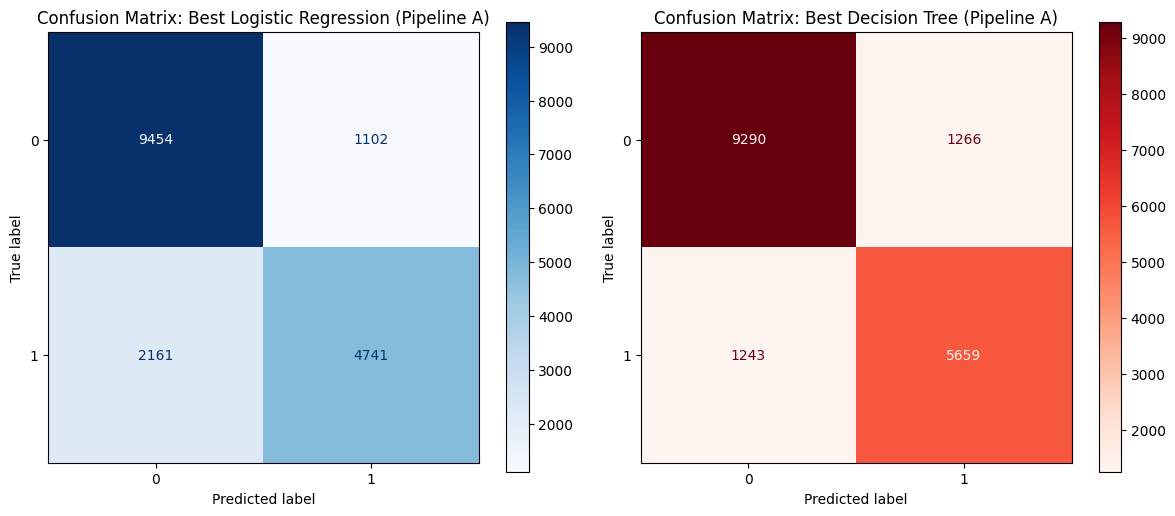

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    logreg_pipeline_A, X_test, y_test,
    ax=axes[0], cmap="Blues"
)
axes[0].set_title("Confusion Matrix: Best Logistic Regression (Pipeline A)")

ConfusionMatrixDisplay.from_estimator(
    tree_pipeline_A, X_test, y_test,
    ax=axes[1], cmap="Reds"
)
axes[1].set_title("Confusion Matrix: Best Decision Tree (Pipeline A)")

plt.tight_layout()
plt.show()

##### Observations

Decision Tree correctly predicts more cancelled and non-cancelled bookings.

Decision Tree with Pipeline A is better because it has the highest test accuracy and F1-score among the four models. 
However, its high training accuracy compared to test accuracy also indicates some overfitting.

#### Task 6 - Final Observations

1. Which preprocessing-model combination gives the best overall result?

 Decision Tree + Pipeline A (StandardScaler) gives the best overall result, with 85.63% test accuracy and 0.819 F1-score.However it shows overfitting because its training accuracy is much higher than its test accuracy.



2. Does StandardScaler or MinMaxScaler affect Logistic Regression more?

 Yes, Logistic Regression is affected slightly.
 StandardScaler gives better results than MinMaxScaler:

 Accuracy: 81.31% → 80.83%
 F1-score: 0.744 → 0.737

So, StandardScaler performs slightly better for Logistic Regression.



3. Does scaling make a major difference for Decision Tree?

 No. The difference is almost negligible.

 StandardScaler: 85.63%
 MinMaxScaler: 85.62%

 This shows that scaling has very little effect on the Decision Tree.



4. Short observations

 Decision Tree performed better than Logistic Regression based on test accuracy and F1-score.

 Pipeline A with StandardScaler gave the best overall result.

 Logistic Regression was slightly better with StandardScaler than MinMaxScaler.

 Scaling had almost no effect on the Decision Tree, as both pipelines gave nearly identical results.

 The Decision Tree confusion matrix shows more correctly classified bookings, but its high training accuracy (99.67%) compared with test accuracy (85.63%) suggests some overfitting.



#### Conclusion

Overall, Decision Tree with StandardScaler performed the best. Scaling made a small difference to Logistic Regression but almost no difference to Decision Tree. The Decision Tree also shows some overfitting because its training accuracy is much higher than its test accuracy.